# Model Evaluation and Predictions
**Task:** Evaluate the trained U-Net baseline model on validation and test splits.

**Inputs:**
- `data/processed/metadata.csv` (split column: train / val / test)
- `outputs/prajwal/checkpoints/best_model.pth` 

**Outputs:**
- `outputs/saikiran/metrics_summary.csv` — per-split metric table
- `outputs/saikiran/confusion_matrix.png`
- `outputs/saikiran/prediction_masks/` — saved prediction PNGs
- `outputs/saikiran/visual_comparisons.png` — side-by-side prediction plots

## 1. Imports and Project Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    accuracy_score
)

import warnings
warnings.filterwarnings('ignore')

# ── Project root ───────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

METADATA_PATH  = PROJECT_ROOT / "data" / "processed" / "metadata.csv"
CHECKPOINT     = PROJECT_ROOT / "outputs" / "prajwal" / "checkpoints" / "best_model.pth"
OUT_DIR        = PROJECT_ROOT / "outputs" / "saikiran"
MASK_OUT_DIR   = OUT_DIR / "prediction_masks"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MASK_OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT  :", PROJECT_ROOT)
print("metadata.csv  :", METADATA_PATH.exists())
print("Checkpoint    :", CHECKPOINT.exists())
print("Device        :", DEVICE)

PROJECT_ROOT  : C:\Users\saiki\PycharmProjects\flood_project_Clean
metadata.csv  : True
Checkpoint    : True
Device        : cpu


## 2. Configuration

In [3]:
IMG_SIZE    = 256
BATCH_SIZE  = 8
IN_CHANNELS = 6      # PRE (3ch) + POST (3ch)
THRESHOLD   = 0.5    # sigmoid threshold for binary prediction

print(f"IMG_SIZE   : {IMG_SIZE}")
print(f"BATCH_SIZE : {BATCH_SIZE}")
print(f"Threshold  : {THRESHOLD}")

IMG_SIZE   : 256
BATCH_SIZE : 8
Threshold  : 0.5


## 3. U-Net Model Definition


In [4]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=6, out_channels=1, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder  = nn.ModuleList()
        self.pool     = nn.MaxPool2d(2, 2)
        self.decoder  = nn.ModuleList()
        self.upconvs  = nn.ModuleList()

        ch = in_channels
        for f in features:
            self.encoder.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoder.append(DoubleConv(f * 2, f))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i, (upconv, dec) in enumerate(zip(self.upconvs, self.decoder)):
            x = upconv(x)
            skip = skips[i]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = torch.cat([skip, x], dim=1)
            x = dec(x)
        return self.final_conv(x)


model = UNet(in_channels=IN_CHANNELS, out_channels=1).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.eval()
print("Model loaded from:", CHECKPOINT)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded from: C:\Users\saiki\PycharmProjects\flood_project_Clean\outputs\prajwal\checkpoints\best_model.pth
Parameters: 31,039,361


## 4. Dataset

In [5]:
def read_tif_as_tensor(path, img_size):
    path = PROJECT_ROOT / path if not Path(path).is_absolute() else Path(path)
    with rasterio.open(path) as src:
        arr = src.read()
    if arr.shape[0] == 1:
        arr = np.repeat(arr, 3, axis=0)
    arr = arr[:3].astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8) * 255.0
    arr = arr.astype(np.uint8)
    img = Image.fromarray(np.transpose(arr, (1, 2, 0)))
    img = img.resize((img_size, img_size), Image.BILINEAR)
    tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
    return tensor


def read_mask_as_tensor(path, img_size):
    path = PROJECT_ROOT / path if not Path(path).is_absolute() else Path(path)
    arr = np.array(Image.open(path).convert("L")).astype(np.float32)
    arr = (arr > 0).astype(np.float32)
    mask = Image.fromarray(arr)
    mask = mask.resize((img_size, img_size), Image.NEAREST)
    return torch.from_numpy(np.array(mask)).unsqueeze(0)


class FloodDataset(Dataset):
    def __init__(self, df, img_size=256):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        pre  = read_tif_as_tensor(row["pre_path"],  self.img_size)
        post = read_tif_as_tensor(row["post_path"], self.img_size)
        mask = read_mask_as_tensor(row["mask_path"], self.img_size)
        image = torch.cat([pre, post], dim=0)
        return image, mask, row["sample_id"]


df = pd.read_csv(METADATA_PATH)
df = df[df["mask_status"] == "OK"].reset_index(drop=True)

val_df  = df[df["split"] == "val"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

val_loader  = DataLoader(FloodDataset(val_df,  IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(FloodDataset(test_df, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Val samples : {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Val samples : 30
Test samples: 31


## 5. Metric Functions

In [6]:
def compute_metrics(all_preds, all_targets):
    """
    all_preds, all_targets: flat numpy arrays of 0/1 values.
    Returns dict of IoU, Dice/F1, Precision, Recall, Accuracy.
    """
    iou       = jaccard_score(all_targets, all_preds, zero_division=0)
    dice      = f1_score(all_targets, all_preds, zero_division=0)
    precision = precision_score(all_targets, all_preds, zero_division=0)
    recall    = recall_score(all_targets, all_preds, zero_division=0)
    accuracy  = accuracy_score(all_targets, all_preds)

    return {
        "IoU"      : round(iou, 4),
        "Dice/F1"  : round(dice, 4),
        "Precision": round(precision, 4),
        "Recall"   : round(recall, 4),
        "Accuracy" : round(accuracy, 4),
    }


def run_evaluation(loader, split_name, save_masks=False):
    """
    Runs model inference on a DataLoader.
    Returns metrics dict and collected predictions/targets for confusion matrix.
    """
    all_preds   = []
    all_targets = []
    saved_examples = []  # (post_img_np, gt_mask_np, pred_mask_np, sample_id)

    model.eval()
    with torch.no_grad():
        for imgs, masks, sample_ids in loader:
            imgs  = imgs.to(DEVICE)
            masks = masks.to(DEVICE)

            logits = model(imgs)
            probs  = torch.sigmoid(logits)
            preds  = (probs > THRESHOLD).float()

            # Flatten for sklearn metrics
            all_preds.append(preds.cpu().numpy().flatten())
            all_targets.append(masks.cpu().numpy().flatten())

            # Save first few prediction masks
            if save_masks:
                for i in range(len(sample_ids)):
                    sid       = sample_ids[i]
                    pred_np   = preds[i, 0].cpu().numpy()      # H W
                    target_np = masks[i, 0].cpu().numpy()      # H W
                    post_np   = imgs[i, 3:6].cpu().numpy()     # post 3ch
                    post_np   = np.transpose(post_np, (1, 2, 0))  # H W 3

                    # Save binary prediction mask as PNG
                    pred_img = Image.fromarray((pred_np * 255).astype(np.uint8))
                    pred_img.save(MASK_OUT_DIR / f"{sid}_pred.png")

                    saved_examples.append((post_np, target_np, pred_np, sid))

    all_preds   = np.concatenate(all_preds).astype(int)
    all_targets = np.concatenate(all_targets).astype(int)

    metrics = compute_metrics(all_preds, all_targets)
    print(f"\n── {split_name} Results ──────────────────────")
    for k, v in metrics.items():
        print(f"  {k:12s}: {v:.4f}")

    return metrics, all_preds, all_targets, saved_examples

print("Metric functions ready.")

Metric functions ready.


## 6. Evaluate on Validation Split

In [7]:
val_metrics, val_preds, val_targets, val_examples = run_evaluation(
    val_loader, "Validation", save_masks=True
)


── Validation Results ──────────────────────
  IoU         : 0.3242
  Dice/F1     : 0.4897
  Precision   : 0.3984
  Recall      : 0.6352
  Accuracy    : 0.9835


## 7. Evaluate on Test Split

In [8]:
test_metrics, test_preds, test_targets, test_examples = run_evaluation(
    test_loader, "Test", save_masks=True
)


── Test Results ──────────────────────
  IoU         : 0.3140
  Dice/F1     : 0.4779
  Precision   : 0.3955
  Recall      : 0.6038
  Accuracy    : 0.9749


## 8. Metrics Summary Table

In [9]:
summary_df = pd.DataFrame({
    "Metric"    : list(val_metrics.keys()),
    "Validation": list(val_metrics.values()),
    "Test"      : list(test_metrics.values()),
})

print("=" * 45)
print("EVALUATION SUMMARY")
print("=" * 45)
print(summary_df.to_string(index=False))

summary_df.to_csv(OUT_DIR / "metrics_summary.csv", index=False)
print("\nSaved:", OUT_DIR / "metrics_summary.csv")

EVALUATION SUMMARY
   Metric  Validation   Test
      IoU      0.3242 0.3140
  Dice/F1      0.4897 0.4779
Precision      0.3984 0.3955
   Recall      0.6352 0.6038
 Accuracy      0.9835 0.9749

Saved: C:\Users\saiki\PycharmProjects\flood_project_Clean\outputs\saikiran\metrics_summary.csv


## 9. Confusion Matrix

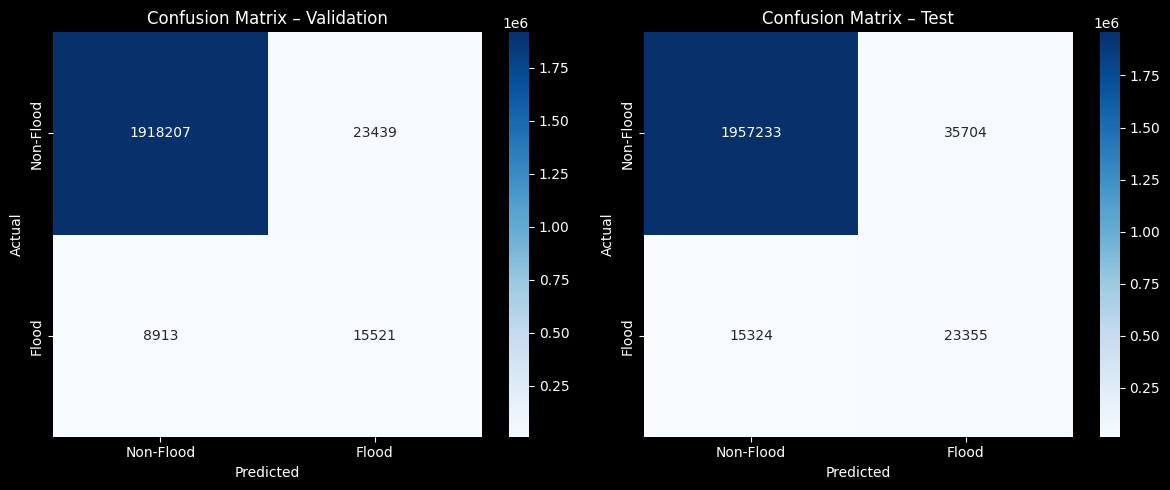

Saved: C:\Users\saiki\PycharmProjects\flood_project_Clean\outputs\saikiran\confusion_matrix.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, targets, title in [
    (axes[0], val_preds,  val_targets,  "Validation"),
    (axes[1], test_preds, test_targets, "Test"),
]:
    cm = confusion_matrix(targets, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Non-Flood", "Flood"],
        yticklabels=["Non-Flood", "Flood"]
    )
    ax.set_title(f"Confusion Matrix – {title}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()
print("Saved:", OUT_DIR / "confusion_matrix.png")

## 10. Visual Comparisons – POST Image | Ground Truth | Prediction

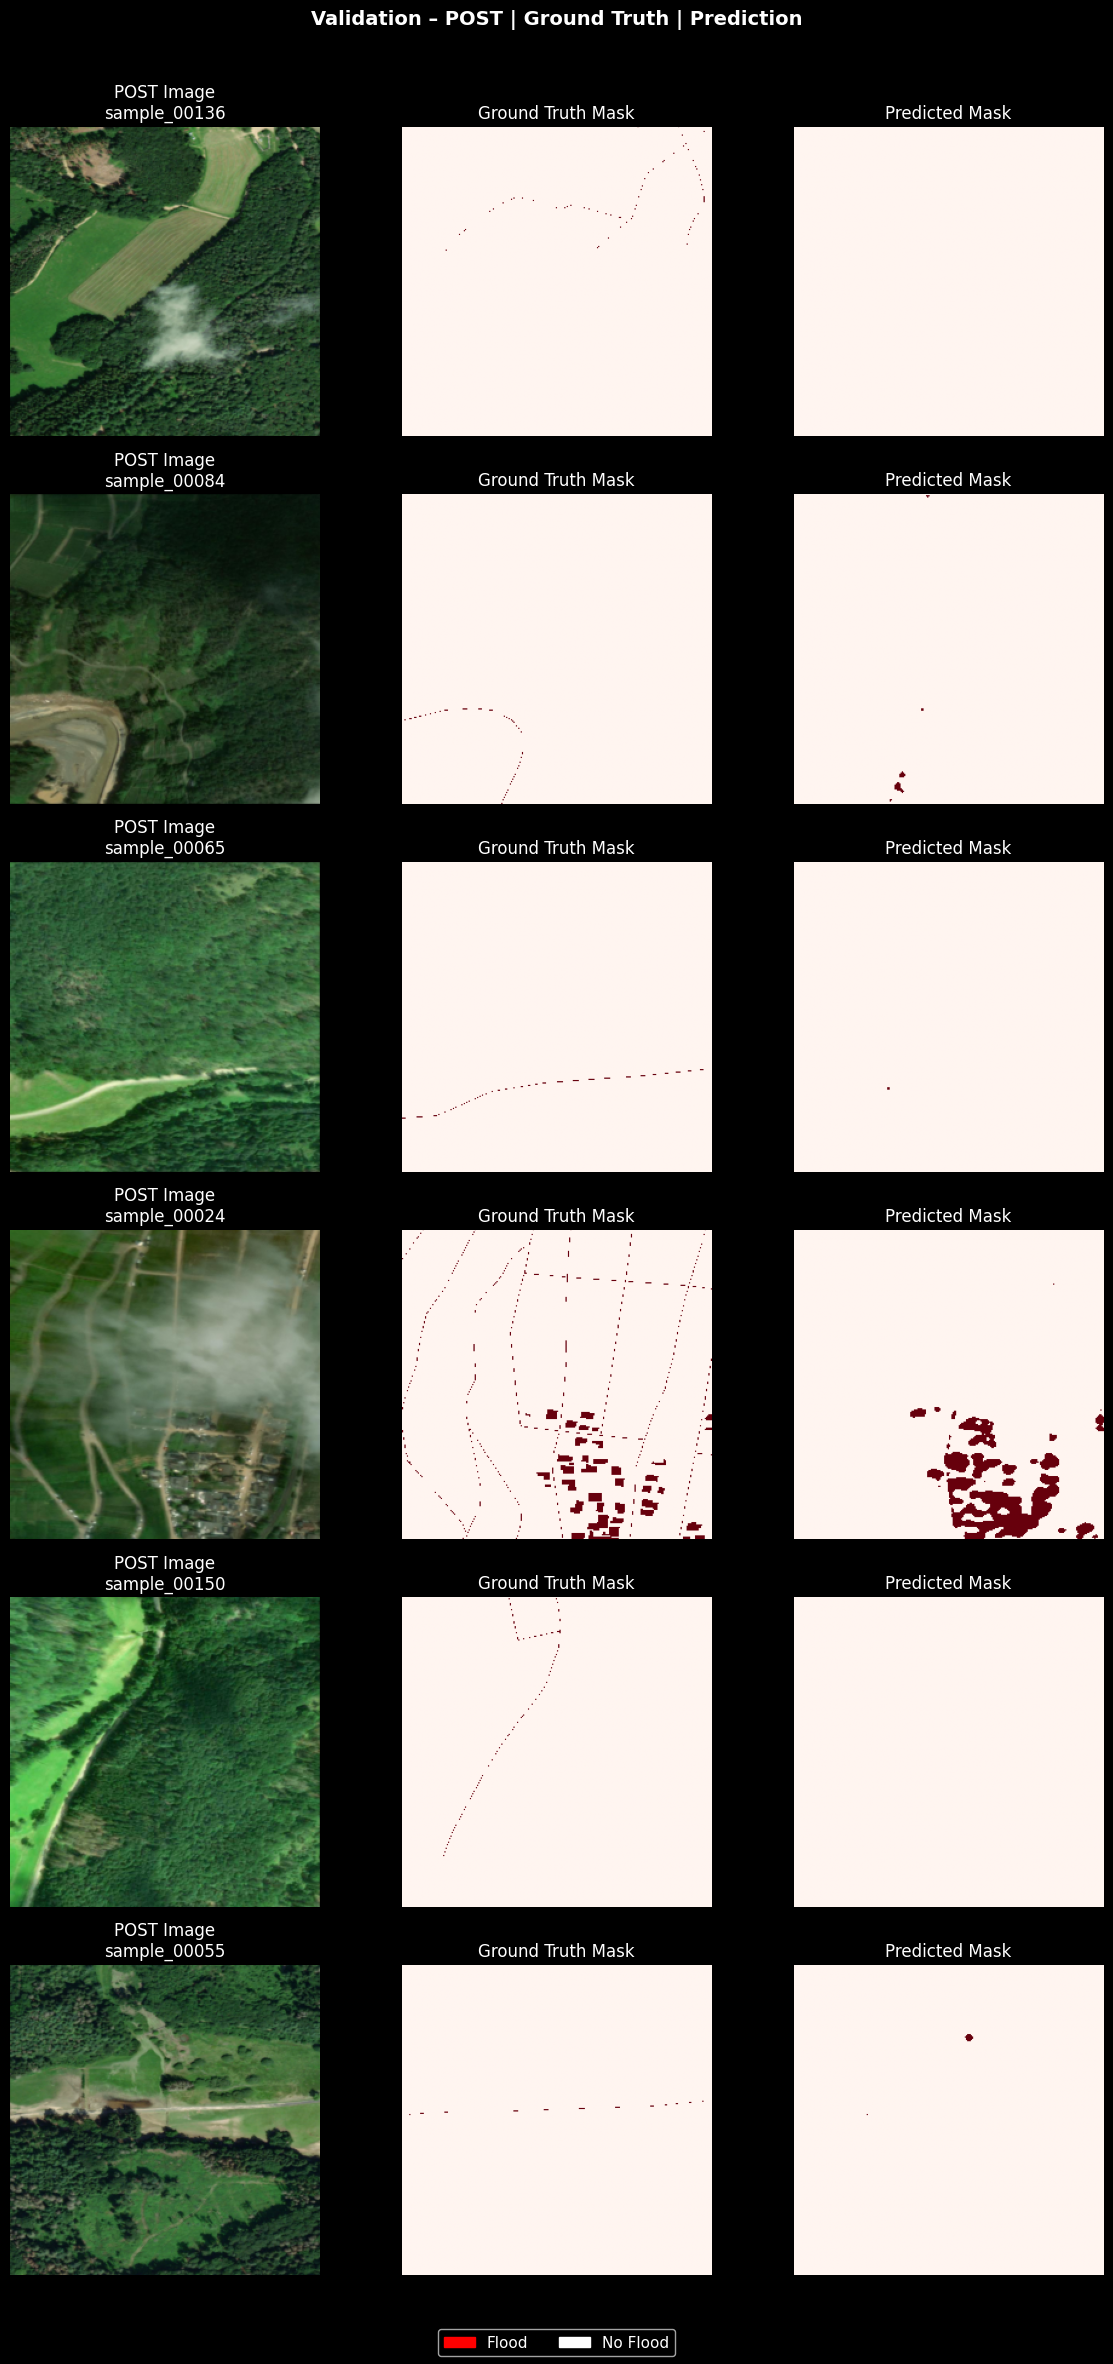

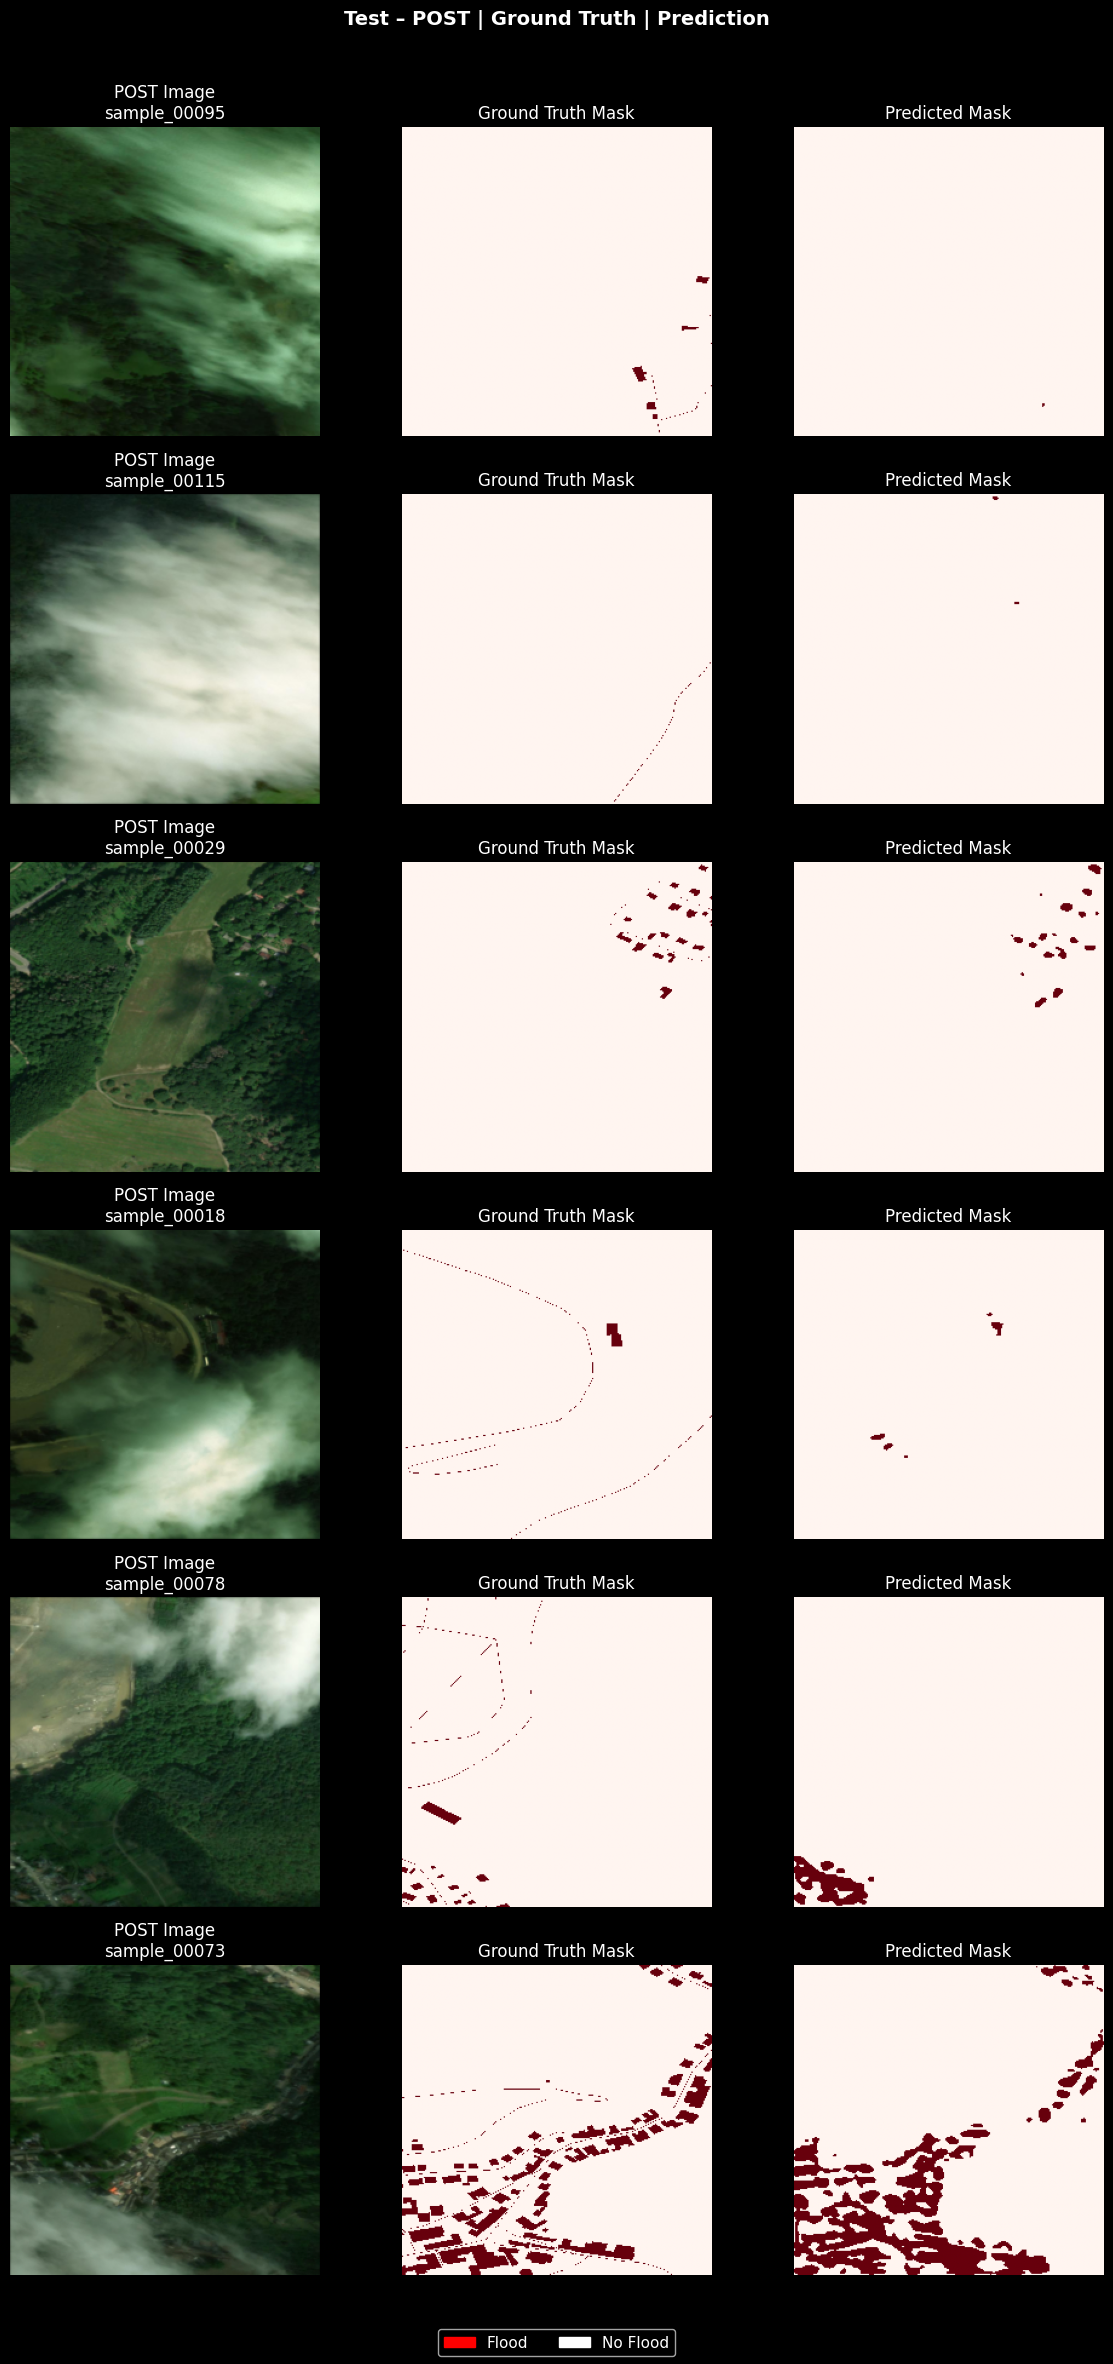

Saved visual comparisons to: C:\Users\saiki\PycharmProjects\flood_project_Clean\outputs\saikiran


In [11]:
def plot_comparisons(examples, title, n=6):
    examples = examples[:n]
    fig, axes = plt.subplots(len(examples), 3, figsize=(12, 4 * len(examples)))
    if len(examples) == 1:
        axes = [axes]

    for row, (post_np, gt_np, pred_np, sid) in enumerate(examples):
        # POST image — clip to [0,1] for display
        post_disp = np.clip(post_np, 0, 1)

        axes[row][0].imshow(post_disp)
        axes[row][0].set_title(f"POST Image\n{sid}")
        axes[row][0].axis("off")

        axes[row][1].imshow(gt_np, cmap="Reds", vmin=0, vmax=1)
        axes[row][1].set_title("Ground Truth Mask")
        axes[row][1].axis("off")

        axes[row][2].imshow(pred_np, cmap="Reds", vmin=0, vmax=1)
        axes[row][2].set_title("Predicted Mask")
        axes[row][2].axis("off")

    flood_patch    = mpatches.Patch(color="red",  label="Flood")
    no_flood_patch = mpatches.Patch(color="white", label="No Flood", edgecolor="black")
    fig.legend(handles=[flood_patch, no_flood_patch], loc="lower center", ncol=2, fontsize=11)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0.03, 1, 0.97])
    return fig


# Validation visual comparisons
fig_val = plot_comparisons(val_examples, "Validation – POST | Ground Truth | Prediction")
fig_val.savefig(OUT_DIR / "val_visual_comparisons.png", dpi=150)
plt.show()

# Test visual comparisons
fig_test = plot_comparisons(test_examples, "Test – POST | Ground Truth | Prediction")
fig_test.savefig(OUT_DIR / "test_visual_comparisons.png", dpi=150)
plt.show()

print("Saved visual comparisons to:", OUT_DIR)

## 11. Per-Image IoU Distribution

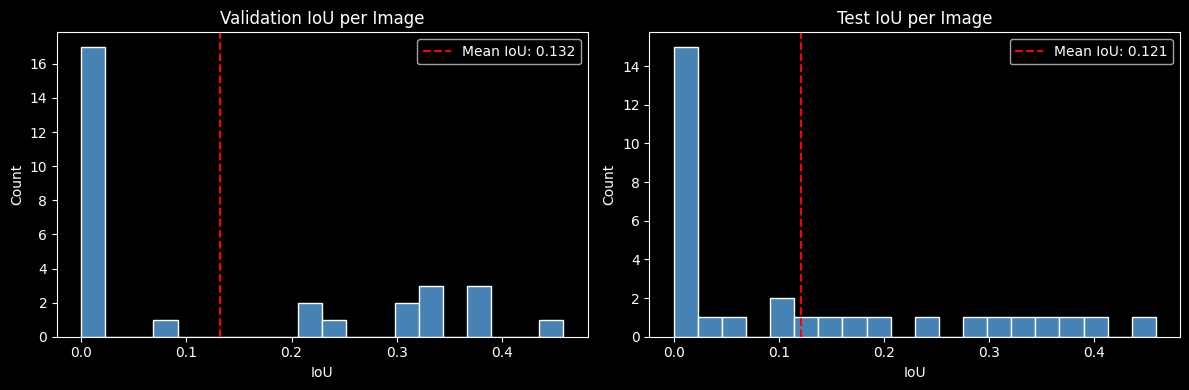

Saved: C:\Users\saiki\PycharmProjects\flood_project_Clean\outputs\saikiran\iou_distribution.png


In [12]:
def per_image_iou(loader):
    ious = []
    model.eval()
    with torch.no_grad():
        for imgs, masks, _ in loader:
            imgs  = imgs.to(DEVICE)
            preds = (torch.sigmoid(model(imgs)) > THRESHOLD).float()
            for i in range(imgs.size(0)):
                p = preds[i, 0].cpu().numpy().flatten().astype(int)
                t = masks[i, 0].numpy().flatten().astype(int)
                iou = jaccard_score(t, p, zero_division=0)
                ious.append(iou)
    return ious


val_ious  = per_image_iou(val_loader)
test_ious = per_image_iou(test_loader)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ious, title in [
    (axes[0], val_ious,  "Validation IoU per Image"),
    (axes[1], test_ious, "Test IoU per Image"),
]:
    ax.hist(ious, bins=20, color="steelblue", edgecolor="white")
    ax.axvline(np.mean(ious), color="red", linestyle="--", label=f"Mean IoU: {np.mean(ious):.3f}")
    ax.set_title(title)
    ax.set_xlabel("IoU")
    ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "iou_distribution.png", dpi=150)
plt.show()
print("Saved:", OUT_DIR / "iou_distribution.png")

## 12. Summary

In [14]:
print("=" * 50)
print("EVALUATION SUMMARY")
print("=" * 50)
print(f"Model        : U-Net baseline ")
print(f"Checkpoint   : outputs/prajwal/checkpoints/best_model.pth")
print(f"Threshold    : {THRESHOLD}")
print()
print(f"{'Metric':<14} {'Validation':>12} {'Test':>12}")
print("-" * 40)
for k in val_metrics:
    print(f"{k:<14} {val_metrics[k]:>12.4f} {test_metrics[k]:>12.4f}")
print()
print("Outputs saved to: outputs/saikiran/")
print("  - metrics_summary.csv")
print("  - confusion_matrix.png")
print("  - val_visual_comparisons.png")
print("  - test_visual_comparisons.png")
print("  - iou_distribution.png")
print("  - prediction_masks/ (per-sample PNGs)")

EVALUATION SUMMARY
Model        : U-Net baseline 
Checkpoint   : outputs/prajwal/checkpoints/best_model.pth
Threshold    : 0.5

Metric           Validation         Test
----------------------------------------
IoU                  0.3242       0.3140
Dice/F1              0.4897       0.4779
Precision            0.3984       0.3955
Recall               0.6352       0.6038
Accuracy             0.9835       0.9749

Outputs saved to: outputs/saikiran/
  - metrics_summary.csv
  - confusion_matrix.png
  - val_visual_comparisons.png
  - test_visual_comparisons.png
  - iou_distribution.png
  - prediction_masks/ (per-sample PNGs)


## 13. Analysis

The baseline U-Net model achieves a Test IoU of **0.3138** and Dice/F1 of **0.4777**, 
indicating moderate overlap between predicted and ground truth flood regions.

**Recall (0.6246)** is notably higher than **Precision (0.3867)**, meaning the model 
successfully detects a large proportion of actual flood pixels but also produces 
false positives — predicting flood in areas that are not flooded. This is a common 
behaviour in baseline segmentation models trained on imbalanced datasets where 
flood pixels are the minority class.

**Accuracy (0.9740)** is high but misleading — since the majority of pixels are 
non-flood, even a model biased toward the background class will score highly on 
accuracy. IoU and Dice are more meaningful metrics for this task.

**Validation vs Test consistency** — Val IoU (0.3258) and Test IoU (0.3138) are 
close, indicating the model generalises reasonably and is not overfitted to the 
validation split.

Overall, the baseline establishes a solid reference point. The higher recall 
suggests the model is learning flood patterns, but precision needs improvement — 
this is the motivation for the improved model (Divya's notebook), which aims to 
reduce false positives through architectural or training enhancements.